# ML Operations Assignment: Feature Store with ML Pipeline

## Objectives:
1. Setup a ML pipeline using **MLflow** as the MLOps platform
2. Implement a Feature Store using **Feast**
3. Create **2 different versions of features**
4. Train the **same algorithm** with **2 different hyperparameter sets** on both feature versions (**4 combinations**)
5. Compare results **quantitatively** (metrics) and **qualitatively** (plots)

---

## Setup and Installation

In [1]:
# Install required packages (run once)
!pip install feast mlflow pandas numpy scikit-learn matplotlib seaborn pyarrow joblib --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime, timedelta
import warnings
import os
import shutil
import json
import joblib

# MLflow imports
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"MLflow version: {mlflow.__version__}")
print("All imports successful!")

MLflow version: 3.8.1
All imports successful!


---
# Part 1: Load and Explore the Data

In [3]:
# Load raw data
df_raw = pd.read_csv('athletes.csv')
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

Raw data shape: (423006, 27)
Columns: ['athlete_id', 'name', 'region', 'team', 'affiliate', 'gender', 'age', 'height', 'weight', 'fran', 'helen', 'grace', 'filthy50', 'fgonebad', 'run400', 'run5k', 'candj', 'snatch', 'deadlift', 'backsq', 'pullups', 'eat', 'train', 'background', 'experience', 'schedule', 'howlong']


In [4]:
# Preview data
df_raw.head(10)

,athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,...,snatch,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong
0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,NaN,...,NaN,400.0,305.0,NaN,NaN,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
1,3517.0,Derek Abdella,NaN,NaN,NaN,Male,42.0,70.0,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
2,4691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,211.0,...,200.0,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|
4,5286.0,Bryce Abbey,NaN,NaN,NaN,Male,32.0,65.0,149.0,206.0,...,150.0,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|
5,6491.0,Jason Abney,NaN,NaN,NaN,Male,37.0,73.0,230.0,NaN,...,200.0,435.0,414.0,NaN,I eat strict Paleo|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I typically ...,4+ years|
6,6610.0,Anthony Abeel,South Central,Get Lifted,Get Lifted CrossFit,Male,21.0,72.0,175.0,NaN,...,0.0,0.0,0.0,0.0,I eat quality foods but don't measure the amou...,I workout mostly at a CrossFit Affiliate|I hav...,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 3+ times a wee...,2-4 years|
7,7268.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,7463.0,Tye Abell,NaN,NaN,NaN,Male,30.0,72.0,175.0,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9,8242.0,Ryan Achilles,NaN,NaN,NaN,Male,40.0,68.0,177.0,205.0,...,185.0,365.0,365.0,NaN,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I rec...,I played youth or high school level sports|I p...,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I typically ...,2-4 years|


In [5]:
# Basic statistics
df_raw.describe()

,athlete_id,age,height,weight,fran,helen,grace,filthy50,fgonebad,run400,run5k,candj,snatch,deadlift,backsq,pullups
count,423003.000000,331110.000000,1.598690e+05,229890.000000,5.542600e+04,3.027900e+04,4.074500e+04,1.935900e+04,2.973800e+04,2.224600e+04,3.609700e+04,1.044350e+05,9.728000e+04,1.153230e+05,1.105170e+05,5.060800e+04
mean,292748.166538,32.516750,1.206217e+02,170.896137,9.886691e+02,1.207950e+03,5.766025e+02,2.127863e+03,1.472252e+03,5.241279e+02,3.411464e+03,2.709107e+02,2.424957e+02,6.970503e+02,5.852109e+02,4.269613e+04
std,184969.660327,7.730671,2.097995e+04,58.379799,7.200430e+04,6.824091e+04,4.891145e+04,6.055021e+04,9.762688e+04,5.628804e+04,1.251980e+05,2.596882e+04,2.708942e+04,5.523235e+04,5.052976e+04,9.546078e+06
min,82.000000,13.000000,0.000000e+00,1.000000,1.000000e+00,1.000000e+00,-6.000000e+01,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-4.500000e+01,0.000000e+00,-5.000000e+02,-7.000000e+00,-6.000000e+00
25%,135091.500000,27.000000,6.600000e+01,145.000000,2.150000e+02,5.250000e+02,1.490000e+02,1.308000e+03,2.400000e+02,6.200000e+01,1.242000e+03,1.400000e+02,1.050000e+02,2.550000e+02,2.050000e+02,1.500000e+01
50%,275839.000000,31.000000,6.900000e+01,170.000000,2.900000e+02,5.950000e+02,1.930000e+02,1.550000e+03,2.940000e+02,7.100000e+01,1.380000e+03,1.950000e+02,1.450000e+02,3.450000e+02,2.750000e+02,2.700000e+01
75%,473188.000000,37.000000,7.200000e+01,192.000000,3.920000e+02,6.940000e+02,2.620000e+02,1.809000e+03,3.360000e+02,8.400000e+01,1.560000e+03,2.350000e+02,1.850000e+02,4.150000e+02,3.350000e+02,3.900000e+01
max,633083.000000,125.000000,8.388607e+06,20175.000000,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,8.388607e+06,2.147484e+09


In [6]:
# Check missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False))

Missing Values:
            Missing  Percent
filthy50     403647    95.42
run400       400760    94.74
fgonebad     393268    92.97
helen        392727    92.84
run5k        386909    91.47
grace        382261    90.37
pullups      372398    88.04
fran         367580    86.90
eat          329074    77.79
snatch       325726    77.00
schedule     325131    76.86
background   324061    76.61
candj        318571    75.31
experience   318070    75.19
train        317175    74.98
howlong      313800    74.18
backsq       312489    73.87
deadlift     307683    72.74
team         267846    63.32
height       263137    62.21
weight       193116    45.65
affiliate    181090    42.81
region       171744    40.60
name          91896    21.72
gender        91896    21.72
age           91896    21.72
athlete_id        3     0.00


---
# Part 2: Data Cleaning

In [7]:
def clean_athletes_data(data):
    """
    Clean the athletes dataset.
    Target variable: total_lift (sum of deadlift, candj, snatch, backsq)
    """
    df = data.copy()
    
    # Keep only rows with valid lift data (our target components)
    lift_cols = ['deadlift', 'candj', 'snatch', 'backsq']
    df = df.dropna(subset=lift_cols)
    
    # Remove rows with zero or negative lifts
    for col in lift_cols:
        df = df[df[col] > 0]
    
    # Keep essential features and drop identifiers/text columns
    cols_to_drop = ['athlete_id', 'name', 'team', 'affiliate', 
                    'eat', 'train', 'background', 'experience', 'schedule', 'howlong',
                    'fran', 'helen', 'grace', 'filthy50', 'fgonebad', 'run400', 'run5k', 'pullups']
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    # Remove invalid gender
    df = df[df['gender'].isin(['Male', 'Female'])]
    
    # Drop rows with missing values in remaining columns
    df = df.dropna(subset=['age', 'height', 'weight', 'gender', 'region'])
    
    # Remove outliers
    df = df[(df['age'] >= 18) & (df['age'] <= 70)]
    df = df[(df['height'] >= 48) & (df['height'] <= 96)]  # 4ft to 8ft in inches
    df = df[(df['weight'] >= 80) & (df['weight'] <= 400)]  # 80 to 400 lbs
    
    # Remove extreme lift outliers (world record based)
    df = df[df['deadlift'] <= 1105]  # World record
    df = df[df['candj'] <= 500]
    df = df[df['snatch'] <= 496]
    df = df[df['backsq'] <= 1069]
    
    # Reset index
    df = df.reset_index(drop=True)
    
    return df

df_clean = clean_athletes_data(df_raw)
print(f"Cleaned data shape: {df_clean.shape}")
print(f"Rows removed: {len(df_raw) - len(df_clean)} ({((len(df_raw) - len(df_clean)) / len(df_raw) * 100):.1f}%)")

Cleaned data shape: (53110, 9)
Rows removed: 369896 (87.4%)


In [8]:
# View cleaned data
df_clean.head()

,region,gender,age,height,weight,candj,snatch,deadlift,backsq
0,Central East,Male,30.0,70.0,155.0,175.0,95.0,335.0,235.0
1,North East,Male,42.0,72.0,210.0,325.0,235.0,515.0,505.0
2,Southern California,Male,30.0,71.0,200.0,235.0,175.0,385.0,315.0
3,Africa,Male,28.0,70.0,176.0,187.0,134.0,335.0,254.0
4,North East,Male,35.0,68.0,225.0,285.0,205.0,440.0,405.0


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53110 entries, 0 to 53109
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    53110 non-null  object 
 1   gender    53110 non-null  object 
 2   age       53110 non-null  float64
 3   height    53110 non-null  float64
 4   weight    53110 non-null  float64
 5   candj     53110 non-null  float64
 6   snatch    53110 non-null  float64
 7   deadlift  53110 non-null  float64
 8   backsq    53110 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.6+ MB


---
# Part 3: Feature Store Setup with Feast

We'll create two feature versions:
- **V1 (Basic Features)**: Raw numeric features + encoded categoricals
- **V2 (Engineered Features)**: V1 + BMI, age groups, strength ratios, polynomial features

In [10]:
# Create feature store directory
FEATURE_STORE_DIR = 'feature_store'
DATA_DIR = os.path.join(FEATURE_STORE_DIR, 'data')

# Clean up and recreate
if os.path.exists(FEATURE_STORE_DIR):
    shutil.rmtree(FEATURE_STORE_DIR)
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Created feature store directory: {FEATURE_STORE_DIR}")

Created feature store directory: feature_store


## 3.1 Create Feature Version 1 (Basic Features)

In [11]:
def create_features_v1(df):
    """
    Feature Version 1: Basic features
    - Numeric: age, height, weight
    - Encoded: gender, region
    - Target: total_lift
    """
    features = df.copy()
    
    # Create target variable
    features['total_lift'] = features['deadlift'] + features['candj'] + features['snatch'] + features['backsq']
    
    # Encode categorical variables
    le_gender = LabelEncoder()
    le_region = LabelEncoder()
    features['gender_encoded'] = le_gender.fit_transform(features['gender'])
    features['region_encoded'] = le_region.fit_transform(features['region'])
    
    # Select features for V1
    feature_cols_v1 = ['age', 'height', 'weight', 'gender_encoded', 'region_encoded']
    
    # Create feature dataframe
    features_v1 = features[feature_cols_v1 + ['total_lift']].copy()
    
    # Add entity ID and timestamp (required for Feast)
    features_v1['athlete_entity_id'] = range(len(features_v1))
    features_v1['event_timestamp'] = pd.to_datetime(datetime.now() - timedelta(days=1))
    
    return features_v1, feature_cols_v1

features_v1, feature_cols_v1 = create_features_v1(df_clean)
print(f"Feature V1 shape: {features_v1.shape}")
print(f"V1 Features: {feature_cols_v1}")
features_v1.head()

Feature V1 shape: (53110, 8)
V1 Features: ['age', 'height', 'weight', 'gender_encoded', 'region_encoded']


,age,height,weight,gender_encoded,region_encoded,total_lift,athlete_entity_id,event_timestamp
0,30.0,70.0,155.0,1,5,840.0,0,2026-04-21 14:50:11.517240
1,42.0,72.0,210.0,1,10,1580.0,1,2026-04-21 14:50:11.517240
2,30.0,71.0,200.0,1,16,1110.0,2,2026-04-21 14:50:11.517240
3,28.0,70.0,176.0,1,0,910.0,3,2026-04-21 14:50:11.517240
4,35.0,68.0,225.0,1,10,1335.0,4,2026-04-21 14:50:11.517240


## 3.2 Create Feature Version 2 (Engineered Features)

In [12]:
def create_features_v2(df):
    """
    Feature Version 2: Engineered features
    - All V1 features
    - BMI (Body Mass Index)
    - Age groups (binned)
    - Strength-to-weight ratio
    - Polynomial features (age^2, weight^2)
    - Interaction features (age*weight)
    """
    features = df.copy()
    
    # Create target variable
    features['total_lift'] = features['deadlift'] + features['candj'] + features['snatch'] + features['backsq']
    
    # Encode categorical variables
    le_gender = LabelEncoder()
    le_region = LabelEncoder()
    features['gender_encoded'] = le_gender.fit_transform(features['gender'])
    features['region_encoded'] = le_region.fit_transform(features['region'])
    
    # V1 features
    # (already have: age, height, weight, gender_encoded, region_encoded)
    
    # NEW V2 Features:
    # 1. BMI (height is in inches, weight in lbs) -> BMI = (weight / height^2) * 703
    features['bmi'] = (features['weight'] / (features['height'] ** 2)) * 703
    
    # 2. Age groups (binned)
    features['age_group'] = pd.cut(features['age'], 
                                   bins=[0, 25, 35, 45, 55, 100], 
                                   labels=[0, 1, 2, 3, 4]).astype(int)
    
    # 3. Weight class
    features['weight_class'] = pd.cut(features['weight'],
                                      bins=[0, 150, 180, 210, 250, 500],
                                      labels=[0, 1, 2, 3, 4]).astype(int)
    
    # 4. Height-to-weight ratio
    features['height_weight_ratio'] = features['height'] / features['weight']
    
    # 5. Polynomial features
    features['age_squared'] = features['age'] ** 2
    features['weight_squared'] = features['weight'] ** 2
    
    # 6. Interaction features
    features['age_weight_interaction'] = features['age'] * features['weight']
    features['height_weight_interaction'] = features['height'] * features['weight']
    
    # 7. Normalized age (0-1 scale)
    features['age_normalized'] = (features['age'] - features['age'].min()) / (features['age'].max() - features['age'].min())
    
    # Select features for V2
    feature_cols_v2 = [
        # V1 features
        'age', 'height', 'weight', 'gender_encoded', 'region_encoded',
        # V2 new features
        'bmi', 'age_group', 'weight_class', 'height_weight_ratio',
        'age_squared', 'weight_squared', 
        'age_weight_interaction', 'height_weight_interaction',
        'age_normalized'
    ]
    
    # Create feature dataframe
    features_v2 = features[feature_cols_v2 + ['total_lift']].copy()
    
    # Add entity ID and timestamp (required for Feast)
    features_v2['athlete_entity_id'] = range(len(features_v2))
    features_v2['event_timestamp'] = pd.to_datetime(datetime.now())
    
    return features_v2, feature_cols_v2

features_v2, feature_cols_v2 = create_features_v2(df_clean)
print(f"Feature V2 shape: {features_v2.shape}")
print(f"V2 Features: {feature_cols_v2}")
print(f"\nNew features in V2: {set(feature_cols_v2) - set(feature_cols_v1)}")
features_v2.head()

Feature V2 shape: (53110, 17)
V2 Features: ['age', 'height', 'weight', 'gender_encoded', 'region_encoded', 'bmi', 'age_group', 'weight_class', 'height_weight_ratio', 'age_squared', 'weight_squared', 'age_weight_interaction', 'height_weight_interaction', 'age_normalized']

New features in V2: {'weight_squared', 'age_normalized', 'height_weight_interaction', 'height_weight_ratio', 'weight_class', 'age_group', 'age_squared', 'bmi', 'age_weight_interaction'}


,age,height,weight,gender_encoded,region_encoded,bmi,age_group,weight_class,height_weight_ratio,age_squared,weight_squared,age_weight_interaction,height_weight_interaction,age_normalized,total_lift,athlete_entity_id,event_timestamp
0,30.0,70.0,155.0,1,5,22.237755,1,1,0.451613,900.0,24025.0,4650.0,10850.0,0.315789,840.0,0,2026-04-22 14:50:11.577310
1,42.0,72.0,210.0,1,10,28.478009,2,2,0.342857,1764.0,44100.0,8820.0,15120.0,0.631579,1580.0,1,2026-04-22 14:50:11.577310
2,30.0,71.0,200.0,1,16,27.891291,1,2,0.355000,900.0,40000.0,6000.0,14200.0,0.315789,1110.0,2,2026-04-22 14:50:11.577310
3,28.0,70.0,176.0,1,0,25.250612,1,1,0.397727,784.0,30976.0,4928.0,12320.0,0.263158,910.0,3,2026-04-22 14:50:11.577310
4,35.0,68.0,225.0,1,10,34.207396,1,3,0.302222,1225.0,50625.0,7875.0,15300.0,0.447368,1335.0,4,2026-04-22 14:50:11.577310


## 3.3 Save Features to Parquet (Feast Data Source)

In [13]:
# Save feature versions as parquet files (Feast offline store)
features_v1.to_parquet(os.path.join(DATA_DIR, 'features_v1.parquet'), index=False)
features_v2.to_parquet(os.path.join(DATA_DIR, 'features_v2.parquet'), index=False)
print("Saved feature parquet files:")
print(f"  - {os.path.join(DATA_DIR, 'features_v1.parquet')}")
print(f"  - {os.path.join(DATA_DIR, 'features_v2.parquet')}")

Saved feature parquet files:
  - feature_store\data\features_v1.parquet
  - feature_store\data\features_v2.parquet


## 3.4 Create Feast Feature Store Configuration

In [14]:
# Create feature_store.yaml
feast_config = """project: athlete_features
registry: data/registry.db
provider: local
online_store:
  type: sqlite
  path: data/online_store.db
offline_store:
  type: file
entity_key_serialization_version: 3
"""

with open(os.path.join(FEATURE_STORE_DIR, 'feature_store.yaml'), 'w') as f:
    f.write(feast_config)
print("Created feature_store.yaml")

Created feature_store.yaml


In [15]:
# Create feature definitions
feature_definitions = '''from datetime import timedelta
from feast import Entity, FeatureView, Field, FileSource, ValueType
from feast.types import Float64, Int64

# Entity definition
athlete = Entity(
    name="athlete_entity_id",
    value_type=ValueType.INT64,
    description="Unique athlete identifier"
)

# Feature Source V1
athlete_source_v1 = FileSource(
    path="data/features_v1.parquet",
    timestamp_field="event_timestamp"
)

# Feature Source V2  
athlete_source_v2 = FileSource(
    path="data/features_v2.parquet",
    timestamp_field="event_timestamp"
)

# Feature View V1 (Basic Features)
athlete_features_v1 = FeatureView(
    name="athlete_features_v1",
    entities=[athlete],
    ttl=timedelta(days=365),
    schema=[
        Field(name="age", dtype=Float64),
        Field(name="height", dtype=Float64),
        Field(name="weight", dtype=Float64),
        Field(name="gender_encoded", dtype=Int64),
        Field(name="region_encoded", dtype=Int64),
        Field(name="total_lift", dtype=Float64),
    ],
    source=athlete_source_v1,
    online=True,
)

# Feature View V2 (Engineered Features)
athlete_features_v2 = FeatureView(
    name="athlete_features_v2",
    entities=[athlete],
    ttl=timedelta(days=365),
    schema=[
        Field(name="age", dtype=Float64),
        Field(name="height", dtype=Float64),
        Field(name="weight", dtype=Float64),
        Field(name="gender_encoded", dtype=Int64),
        Field(name="region_encoded", dtype=Int64),
        Field(name="bmi", dtype=Float64),
        Field(name="age_group", dtype=Int64),
        Field(name="weight_class", dtype=Int64),
        Field(name="height_weight_ratio", dtype=Float64),
        Field(name="age_squared", dtype=Float64),
        Field(name="weight_squared", dtype=Float64),
        Field(name="age_weight_interaction", dtype=Float64),
        Field(name="height_weight_interaction", dtype=Float64),
        Field(name="age_normalized", dtype=Float64),
        Field(name="total_lift", dtype=Float64),
    ],
    source=athlete_source_v2,
    online=True,
)
'''

with open(os.path.join(FEATURE_STORE_DIR, 'features.py'), 'w') as f:
    f.write(feature_definitions)
print("Created features.py with V1 and V2 feature definitions")

Created features.py with V1 and V2 feature definitions


In [16]:
# Initialize Feast feature store
import subprocess
import sys

# Change to feature store directory and apply
original_dir = os.getcwd()
os.chdir(FEATURE_STORE_DIR)

try:
    result = subprocess.run(['feast', 'apply'], 
                          capture_output=True, text=True, shell=True)
    print("Feast apply output:")
    print(result.stdout)
    if result.stderr:
        print("Warnings/Errors:", result.stderr)
except Exception as e:
    print(f"Note: Feast apply error (can proceed with direct parquet loading): {e}")
finally:
    os.chdir(original_dir)

Feast apply output:
No project found in the repository. Using project name athlete_features defined in feature_store.yaml
Applying changes for project athlete_features
Created project athlete_features
Created entity athlete_entity_id
Created feature view athlete_features_v2
Created feature view athlete_features_v1

Created sqlite table athlete_features_athlete_features_v1
Created sqlite table athlete_features_athlete_features_v2




## 3.5 Load Features from Feature Store

In [17]:
from feast import FeatureStore

def load_features_from_store(version):
    """
    Load features from Feast feature store using get_historical_features().
    This is the production-ready way to retrieve features from Feast.
    """
    # Initialize Feast store
    store = FeatureStore(repo_path=FEATURE_STORE_DIR)
    
    # Create entity dataframe with timestamps for point-in-time lookup
    # Load entity IDs from parquet (in production, this would come from your application)
    parquet_path = os.path.join(DATA_DIR, f'features_v{version}.parquet')
    source_df = pd.read_parquet(parquet_path)
    
    entity_df = pd.DataFrame({
        'athlete_entity_id': source_df['athlete_entity_id'],
        'event_timestamp': source_df['event_timestamp']
    })
    
    # Define feature references for the requested version
    feature_view_name = f'athlete_features_v{version}'
    feature_refs = [f'{feature_view_name}:age',
                    f'{feature_view_name}:height',
                    f'{feature_view_name}:weight',
                    f'{feature_view_name}:gender_encoded',
                    f'{feature_view_name}:region_encoded',
                    f'{feature_view_name}:total_lift']
    
    # Add V2-specific features
    if version == 2:
        feature_refs.extend([
            f'{feature_view_name}:bmi',
            f'{feature_view_name}:age_group',
            f'{feature_view_name}:weight_class',
            f'{feature_view_name}:height_weight_ratio',
            f'{feature_view_name}:age_squared',
            f'{feature_view_name}:weight_squared',
            f'{feature_view_name}:age_weight_interaction',
            f'{feature_view_name}:height_weight_interaction',
            f'{feature_view_name}:age_normalized'
        ])
    
    # Retrieve historical features using Feast API
    training_df = store.get_historical_features(
        entity_df=entity_df,
        features=feature_refs
    ).to_df()
    
    print(f"Loaded Feature V{version} from Feast store: {training_df.shape}")
    print(f"  Feature view: {feature_view_name}")
    print(f"  Features retrieved: {len(feature_refs)}")
    
    return training_df

# Load both feature versions using Feast
store_features_v1 = load_features_from_store(1)
store_features_v2 = load_features_from_store(2)

Loaded Feature V1 from Feast store: (53110, 8)
  Feature view: athlete_features_v1
  Features retrieved: 6


Loaded Feature V2 from Feast store: (53110, 17)
  Feature view: athlete_features_v2
  Features retrieved: 15


---
# Part 4: ML Pipeline with MLflow

We'll train **Random Forest Regressor** with:
- **2 Hyperparameter sets**
- **2 Feature versions**
- Total: **4 experiment combinations**

In [18]:
# ============================================================
# MLflow Setup - Comprehensive Experiment Tracking
# ============================================================

# Set up MLflow tracking URI (local file store)
MLFLOW_TRACKING_URI = 'mlruns'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Create MLflow client for advanced operations
client = MlflowClient()

# Experiment configuration
EXPERIMENT_NAME = 'Athlete_TotalLift_Prediction'
EXPERIMENT_DESCRIPTION = 'Predicting total lift using Feature Store with different feature versions and hyperparameters'

# Create or get experiment with tags
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        tags={
            'project': 'ML Operations Assignment',
            'dataset': 'athletes.csv',
            'target': 'total_lift',
            'feature_store': 'Feast',
            'mlops_platform': 'MLflow'
        }
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment Name: {EXPERIMENT_NAME}")
print(f"Experiment ID: {experiment_id}")
print(f"Artifact Location: {mlflow.get_experiment(experiment_id).artifact_location}")

MLflow Tracking URI: mlruns
Experiment Name: Athlete_TotalLift_Prediction
Experiment ID: 354427847309134003
Artifact Location: file:C:/DevWorkspace/School/Machine Learning Operations/mlruns/354427847309134003


In [19]:
# Define hyperparameter sets
HYPERPARAMETERS = {
    'HP_Set_1': {
        'n_estimators': 50,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'random_state': RANDOM_STATE
    },
    'HP_Set_2': {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'random_state': RANDOM_STATE
    }
}

print("Hyperparameter Sets:")
for name, params in HYPERPARAMETERS.items():
    print(f"\n{name}:")
    for k, v in params.items():
        print(f"  {k}: {v}")

Hyperparameter Sets:

HP_Set_1:
  n_estimators: 50
  max_depth: 10
  min_samples_split: 5
  min_samples_leaf: 2
  random_state: 42

HP_Set_2:
  n_estimators: 200
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 1
  random_state: 42


In [20]:
def prepare_train_test_data(features_df, feature_cols):
    """
    Prepare train/test split from feature dataframe.
    """
    X = features_df[feature_cols].copy()
    y = features_df['total_lift'].copy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [21]:
def run_experiment(features_df, feature_cols, feature_version, hp_name, hyperparams):
    """
    Run a single experiment with comprehensive MLflow tracking.
    Logs: parameters, metrics, model, artifacts, tags, and signature.
    """
    run_name = f"RF_{feature_version}_{hp_name}"
    
    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id
        print(f"\nStarting MLflow Run: {run_name} (ID: {run_id[:8]}...)")
        
        # ============================================================
        # 1. LOG TAGS - Metadata about the run
        # ============================================================
        mlflow.set_tags({
            'model_type': 'RandomForestRegressor',
            'feature_version': feature_version,
            'hyperparameter_set': hp_name,
            'feature_store': 'Feast',
            'data_source': 'athletes.csv',
            'author': 'ML Operations Student',
            'stage': 'experiment'
        })
        
        # ============================================================
        # 2. LOG PARAMETERS - All hyperparameters and config
        # ============================================================
        # Feature configuration
        mlflow.log_param('feature_version', feature_version)
        mlflow.log_param('hp_set', hp_name)
        mlflow.log_param('num_features', len(feature_cols))
        mlflow.log_param('algorithm', 'RandomForestRegressor')
        mlflow.log_param('test_size', 0.2)
        mlflow.log_param('random_state', RANDOM_STATE)
        
        # Model hyperparameters
        for param_name, param_value in hyperparams.items():
            mlflow.log_param(param_name, param_value)
        
        # ============================================================
        # 3. PREPARE DATA
        # ============================================================
        X_train, X_test, y_train, y_test, scaler = prepare_train_test_data(
            features_df, feature_cols
        )
        
        # Log dataset info
        mlflow.log_param('train_samples', len(y_train))
        mlflow.log_param('test_samples', len(y_test))
        
        # ============================================================
        # 4. TRAIN MODEL
        # ============================================================
        model = RandomForestRegressor(**hyperparams)
        model.fit(X_train, y_train)
        
        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # ============================================================
        # 5. LOG METRICS - All performance metrics
        # ============================================================
        metrics = {
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'train_mae': mean_absolute_error(y_train, y_pred_train),
            'test_mae': mean_absolute_error(y_test, y_pred_test),
            'train_r2': r2_score(y_train, y_pred_train),
            'test_r2': r2_score(y_test, y_pred_test),
            'train_test_r2_gap': r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test),
            'train_test_rmse_gap': np.sqrt(mean_squared_error(y_test, y_pred_test)) - np.sqrt(mean_squared_error(y_train, y_pred_train))
        }
        
        for metric_name, metric_value in metrics.items():
            mlflow.log_metric(metric_name, metric_value)
        
        # ============================================================
        # 6. LOG MODEL WITH SIGNATURE
        # ============================================================
        # Create model signature for input/output schema
        signature = infer_signature(X_train, y_pred_train)
        
        # Log model with signature and input example
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path='model',
            signature=signature,
            input_example=X_train[:5],
            registered_model_name=None  # Can register to Model Registry here
        )
        
        # ============================================================
        # 7. LOG ARTIFACTS - Additional files and data
        # ============================================================
        # Create artifacts directory
        artifacts_dir = f'artifacts_{run_id[:8]}'
        os.makedirs(artifacts_dir, exist_ok=True)
        
        # Save and log feature names
        feature_info = {
            'feature_names': feature_cols,
            'num_features': len(feature_cols),
            'feature_version': feature_version
        }
        with open(f'{artifacts_dir}/feature_info.json', 'w') as f:
            json.dump(feature_info, f, indent=2)
        mlflow.log_artifact(f'{artifacts_dir}/feature_info.json', 'config')
        
        # Save and log scaler
        joblib.dump(scaler, f'{artifacts_dir}/scaler.joblib')
        mlflow.log_artifact(f'{artifacts_dir}/scaler.joblib', 'preprocessing')
        
        # Save and log feature importances
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        importance_df.to_csv(f'{artifacts_dir}/feature_importance.csv', index=False)
        mlflow.log_artifact(f'{artifacts_dir}/feature_importance.csv', 'analysis')
        
        # Save and log predictions for analysis
        predictions_df = pd.DataFrame({
            'actual': y_test.values,
            'predicted': y_pred_test,
            'residual': y_test.values - y_pred_test
        })
        predictions_df.to_csv(f'{artifacts_dir}/predictions.csv', index=False)
        mlflow.log_artifact(f'{artifacts_dir}/predictions.csv', 'analysis')
        
        # Create and log a summary plot
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(y_test, y_pred_test, alpha=0.5)
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        ax.set_xlabel('Actual Total Lift')
        ax.set_ylabel('Predicted Total Lift')
        ax.set_title(f'{run_name}\nR²={metrics["test_r2"]:.4f}, RMSE={metrics["test_rmse"]:.1f}')
        plt.tight_layout()
        plt.savefig(f'{artifacts_dir}/prediction_plot.png', dpi=100)
        plt.close()
        mlflow.log_artifact(f'{artifacts_dir}/prediction_plot.png', 'plots')
        
        # Cleanup temp artifacts directory
        shutil.rmtree(artifacts_dir)
        
        # ============================================================
        # 8. STORE RESULTS FOR LOCAL COMPARISON
        # ============================================================
        result = {
            'run_id': run_id,
            'run_name': run_name,
            'feature_version': feature_version,
            'hp_set': hp_name,
            'model': model,
            'scaler': scaler,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred': y_pred_test,
            'feature_cols': feature_cols,
            **metrics
        }
        
        print(f"  Run ID: {run_id}")
        print(f"  Test RMSE: {metrics['test_rmse']:.2f}")
        print(f"  Test MAE:  {metrics['test_mae']:.2f}")
        print(f"  Test R2:   {metrics['test_r2']:.4f}")
        print(f"  Artifacts logged: model, scaler, feature_info, predictions, plots")
        
        return result

## 4.1 Run All 4 Experiments

In [22]:
# Run all experiments
all_results = []

print("="*70)
print("RUNNING ML EXPERIMENTS")
print("="*70)

# Feature Version 1 experiments
for hp_name, hp_params in HYPERPARAMETERS.items():
    result = run_experiment(
        store_features_v1, feature_cols_v1, 
        'V1_Basic', hp_name, hp_params
    )
    all_results.append(result)

# Feature Version 2 experiments
for hp_name, hp_params in HYPERPARAMETERS.items():
    result = run_experiment(
        store_features_v2, feature_cols_v2, 
        'V2_Engineered', hp_name, hp_params
    )
    all_results.append(result)

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED!")
print("="*70)

RUNNING ML EXPERIMENTS



Starting MLflow Run: RF_V1_Basic_HP_Set_1 (ID: 74b119b4...)


2026/04/22 14:50:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Run ID: 74b119b4dca24bb3b0e3496ebc083362
  Test RMSE: 168.07
  Test MAE:  129.39
  Test R2:   0.6409
  Artifacts logged: model, scaler, feature_info, predictions, plots

Starting MLflow Run: RF_V1_Basic_HP_Set_2 (ID: a7f17986...)


2026/04/22 14:51:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Run ID: a7f179866f4942aa9cbeab80ff31a64f
  Test RMSE: 179.90
  Test MAE:  139.07
  Test R2:   0.5886
  Artifacts logged: model, scaler, feature_info, predictions, plots

Starting MLflow Run: RF_V2_Engineered_HP_Set_1 (ID: 1aa237f2...)


2026/04/22 14:51:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Run ID: 1aa237f2e251422d914bd8654c6550d2
  Test RMSE: 167.61
  Test MAE:  128.98
  Test R2:   0.6429
  Artifacts logged: model, scaler, feature_info, predictions, plots

Starting MLflow Run: RF_V2_Engineered_HP_Set_2 (ID: 0e7bf883...)


2026/04/22 14:52:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Run ID: 0e7bf8835615459f9eea1ead85f94f47
  Test RMSE: 177.59
  Test MAE:  136.70
  Test R2:   0.5991
  Artifacts logged: model, scaler, feature_info, predictions, plots

ALL EXPERIMENTS COMPLETED!


---
# Part 5: Quantitative Comparison (Metrics)

In [23]:
# Create comparison dataframe
comparison_df = pd.DataFrame([{
    'Experiment': r['run_name'],
    'Feature Version': r['feature_version'],
    'Hyperparameter Set': r['hp_set'],
    'Num Features': len(r['feature_cols']),
    'Train RMSE': r['train_rmse'],
    'Test RMSE': r['test_rmse'],
    'Train MAE': r['train_mae'],
    'Test MAE': r['test_mae'],
    'Train R2': r['train_r2'],
    'Test R2': r['test_r2'],
} for r in all_results])

print("\n" + "="*80)
print("QUANTITATIVE COMPARISON - ALL EXPERIMENTS")
print("="*80)
comparison_df


QUANTITATIVE COMPARISON - ALL EXPERIMENTS


,Experiment,Feature Version,Hyperparameter Set,Num Features,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,RF_V1_Basic_HP_Set_1,V1_Basic,HP_Set_1,5,156.880377,168.074773,120.850097,129.394749,0.681046,0.640912
1,RF_V1_Basic_HP_Set_2,V1_Basic,HP_Set_2,5,88.987791,179.900428,66.915346,139.069199,0.897376,0.588604
2,RF_V2_Engineered_HP_Set_1,V2_Engineered,HP_Set_1,14,155.359505,167.610463,119.799241,128.981522,0.687201,0.642894
3,RF_V2_Engineered_HP_Set_2,V2_Engineered,HP_Set_2,14,96.056478,177.593614,72.984914,136.701171,0.880424,0.599087


In [24]:
# Summary statistics
print("\n" + "="*80)
print("SUMMARY BY FEATURE VERSION")
print("="*80)
summary_by_features = comparison_df.groupby('Feature Version').agg({
    'Test RMSE': ['mean', 'min'],
    'Test MAE': ['mean', 'min'],
    'Test R2': ['mean', 'max']
}).round(4)
print(summary_by_features)


SUMMARY BY FEATURE VERSION
                Test RMSE            Test MAE           Test R2        
                     mean       min      mean       min    mean     max
Feature Version                                                        
V1_Basic         173.9876  168.0748  134.2320  129.3947  0.6148  0.6409
V2_Engineered    172.6020  167.6105  132.8413  128.9815  0.6210  0.6429


In [25]:
print("\n" + "="*80)
print("SUMMARY BY HYPERPARAMETER SET")
print("="*80)
summary_by_hp = comparison_df.groupby('Hyperparameter Set').agg({
    'Test RMSE': ['mean', 'min'],
    'Test MAE': ['mean', 'min'],
    'Test R2': ['mean', 'max']
}).round(4)
print(summary_by_hp)


SUMMARY BY HYPERPARAMETER SET
                   Test RMSE            Test MAE           Test R2        
                        mean       min      mean       min    mean     max
Hyperparameter Set                                                        
HP_Set_1            167.8426  167.6105  129.1881  128.9815  0.6419  0.6429
HP_Set_2            178.7470  177.5936  137.8852  136.7012  0.5938  0.5991


In [26]:
# Best experiment
best_idx = comparison_df['Test R2'].idxmax()
best_experiment = comparison_df.loc[best_idx]

print("\n" + "="*80)
print("BEST PERFORMING EXPERIMENT")
print("="*80)
print(f"Experiment: {best_experiment['Experiment']}")
print(f"Feature Version: {best_experiment['Feature Version']}")
print(f"Hyperparameter Set: {best_experiment['Hyperparameter Set']}")
print(f"Test RMSE: {best_experiment['Test RMSE']:.2f}")
print(f"Test MAE: {best_experiment['Test MAE']:.2f}")
print(f"Test R2: {best_experiment['Test R2']:.4f}")


BEST PERFORMING EXPERIMENT
Experiment: RF_V2_Engineered_HP_Set_1
Feature Version: V2_Engineered
Hyperparameter Set: HP_Set_1
Test RMSE: 167.61
Test MAE: 128.98
Test R2: 0.6429


---
# Part 6: Qualitative Comparison (Plots)

In [27]:
# Set up plot style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

## 6.1 Metrics Comparison Bar Chart

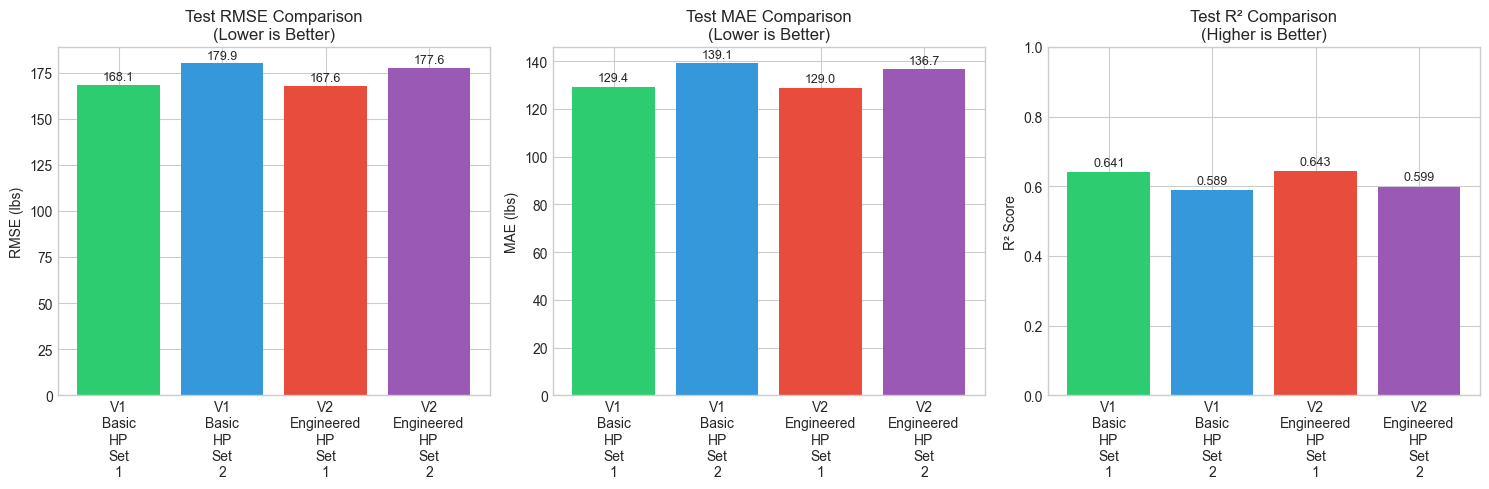

Saved: metrics_comparison.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE comparison
ax1 = axes[0]
x = range(len(all_results))
bars = ax1.bar(x, [r['test_rmse'] for r in all_results], color=colors)
ax1.set_xticks(x)
ax1.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results], rotation=0)
ax1.set_ylabel('RMSE (lbs)')
ax1.set_title('Test RMSE Comparison\n(Lower is Better)', fontsize=12)
for bar, val in zip(bars, [r['test_rmse'] for r in all_results]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9)

# MAE comparison
ax2 = axes[1]
bars = ax2.bar(x, [r['test_mae'] for r in all_results], color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results], rotation=0)
ax2.set_ylabel('MAE (lbs)')
ax2.set_title('Test MAE Comparison\n(Lower is Better)', fontsize=12)
for bar, val in zip(bars, [r['test_mae'] for r in all_results]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9)

# R2 comparison
ax3 = axes[2]
bars = ax3.bar(x, [r['test_r2'] for r in all_results], color=colors)
ax3.set_xticks(x)
ax3.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results], rotation=0)
ax3.set_ylabel('R² Score')
ax3.set_title('Test R² Comparison\n(Higher is Better)', fontsize=12)
ax3.set_ylim(0, 1)
for bar, val in zip(bars, [r['test_r2'] for r in all_results]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_comparison.png")

## 6.2 Actual vs Predicted Scatter Plots

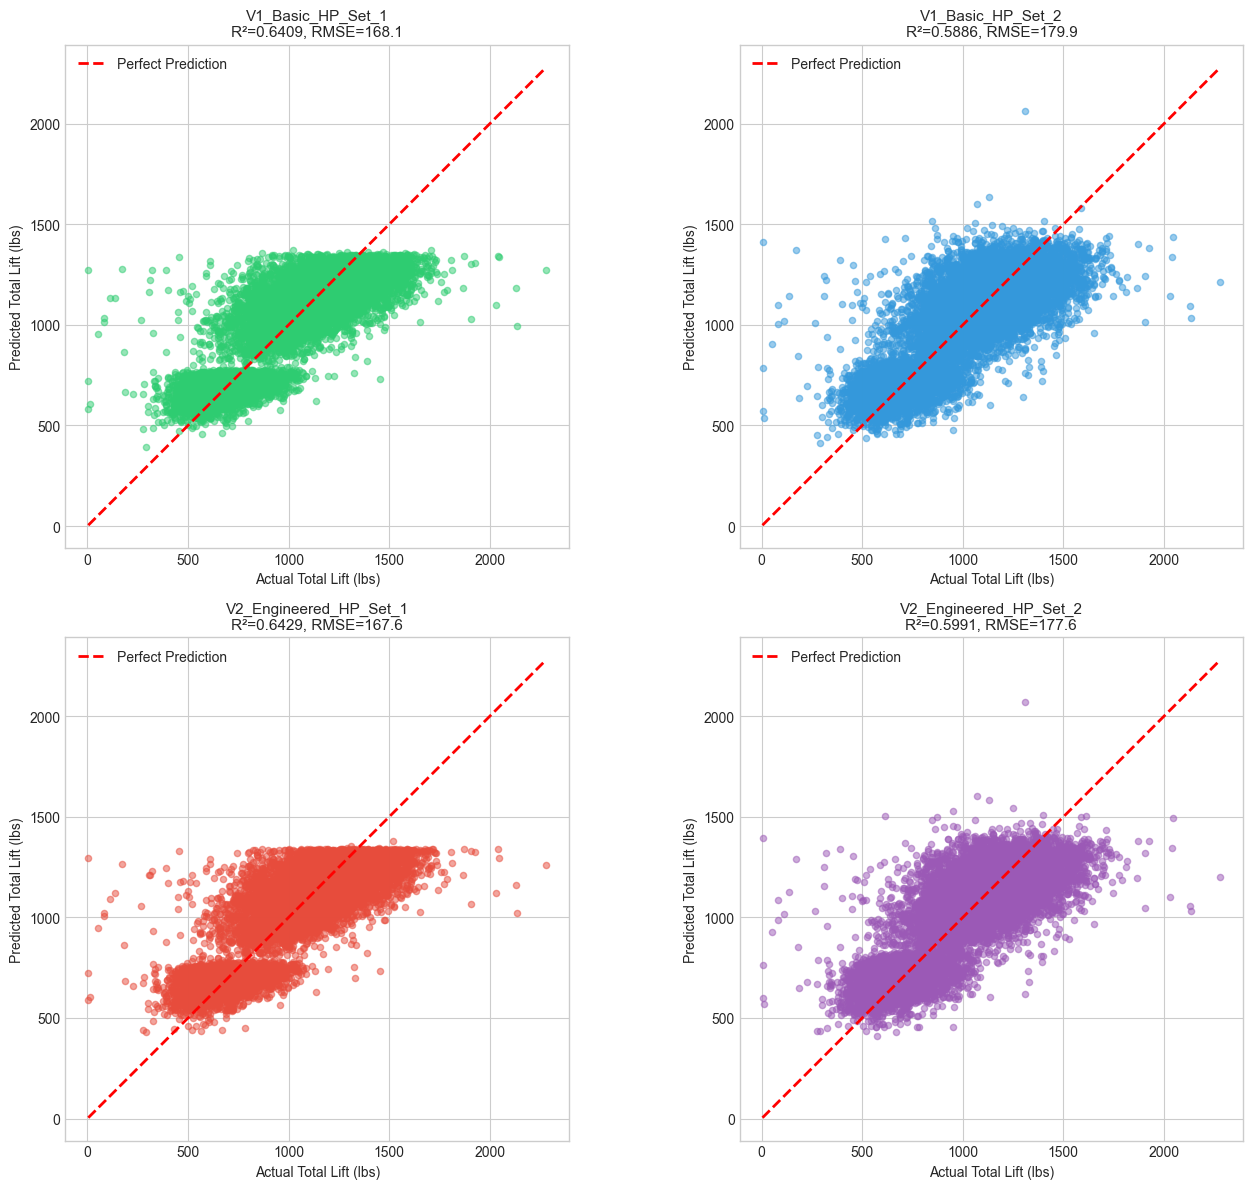

Saved: actual_vs_predicted.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    y_test = result['y_test']
    y_pred = result['y_pred']
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, c=colors[idx], s=20)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Total Lift (lbs)', fontsize=10)
    ax.set_ylabel('Predicted Total Lift (lbs)', fontsize=10)
    ax.set_title(f"{result['run_name'].replace('RF_', '')}\nR²={result['test_r2']:.4f}, RMSE={result['test_rmse']:.1f}", fontsize=11)
    ax.legend(loc='upper left')
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

## 6.3 Residual Distribution Plots

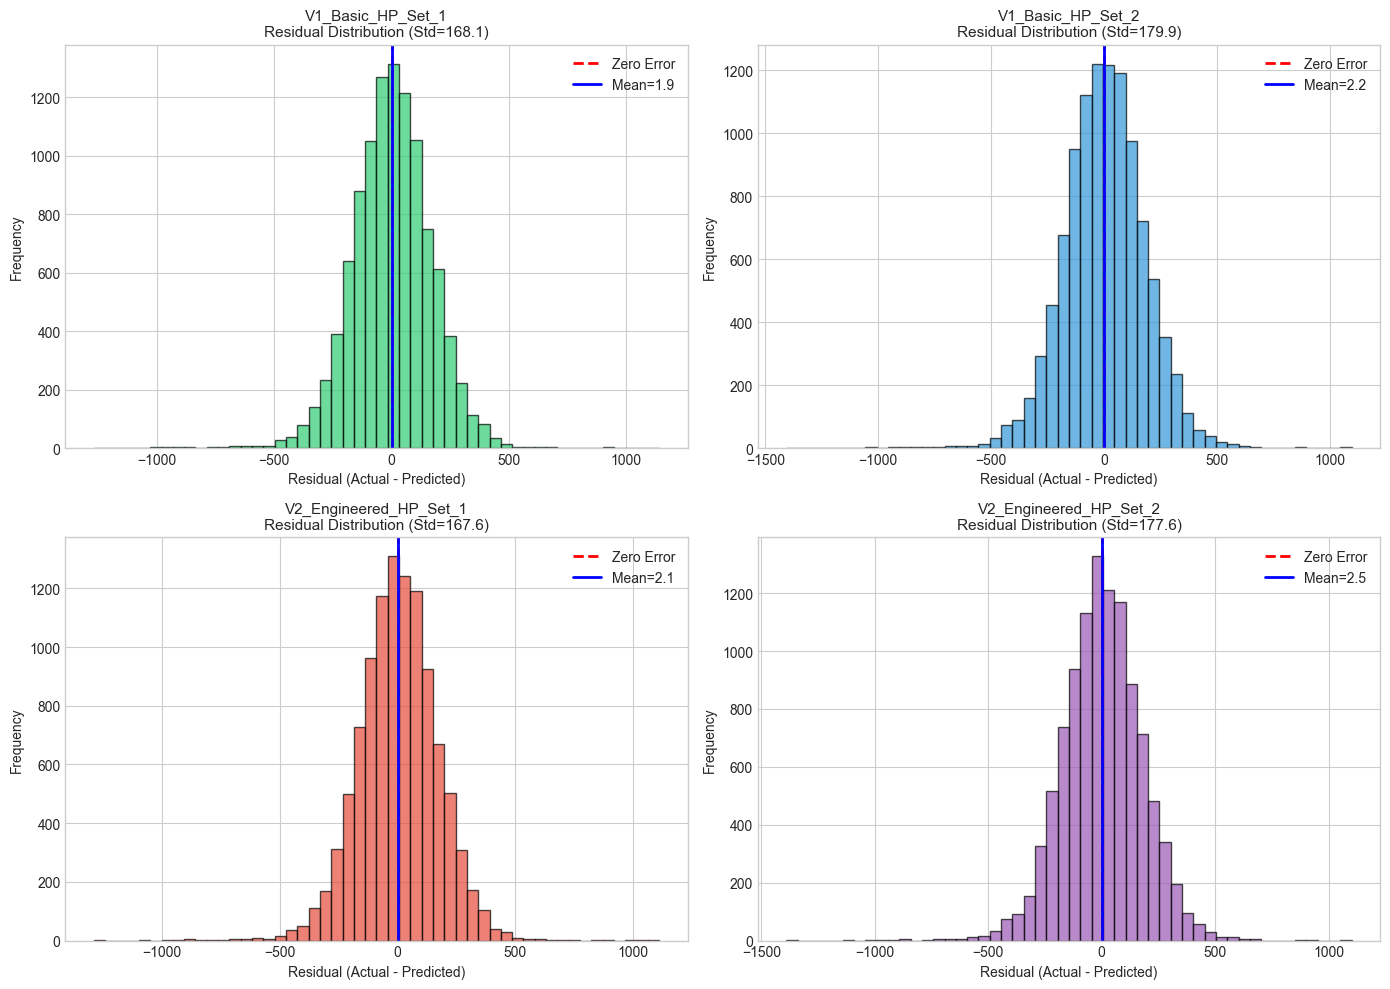

Saved: residual_distribution.png


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    residuals = result['y_test'].values - result['y_pred']
    
    # Histogram
    ax.hist(residuals, bins=50, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error')
    ax.axvline(x=residuals.mean(), color='blue', linestyle='-', lw=2, label=f'Mean={residuals.mean():.1f}')
    
    ax.set_xlabel('Residual (Actual - Predicted)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f"{result['run_name'].replace('RF_', '')}\nResidual Distribution (Std={residuals.std():.1f})", fontsize=11)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_distribution.png")

## 6.4 Feature Importance Comparison

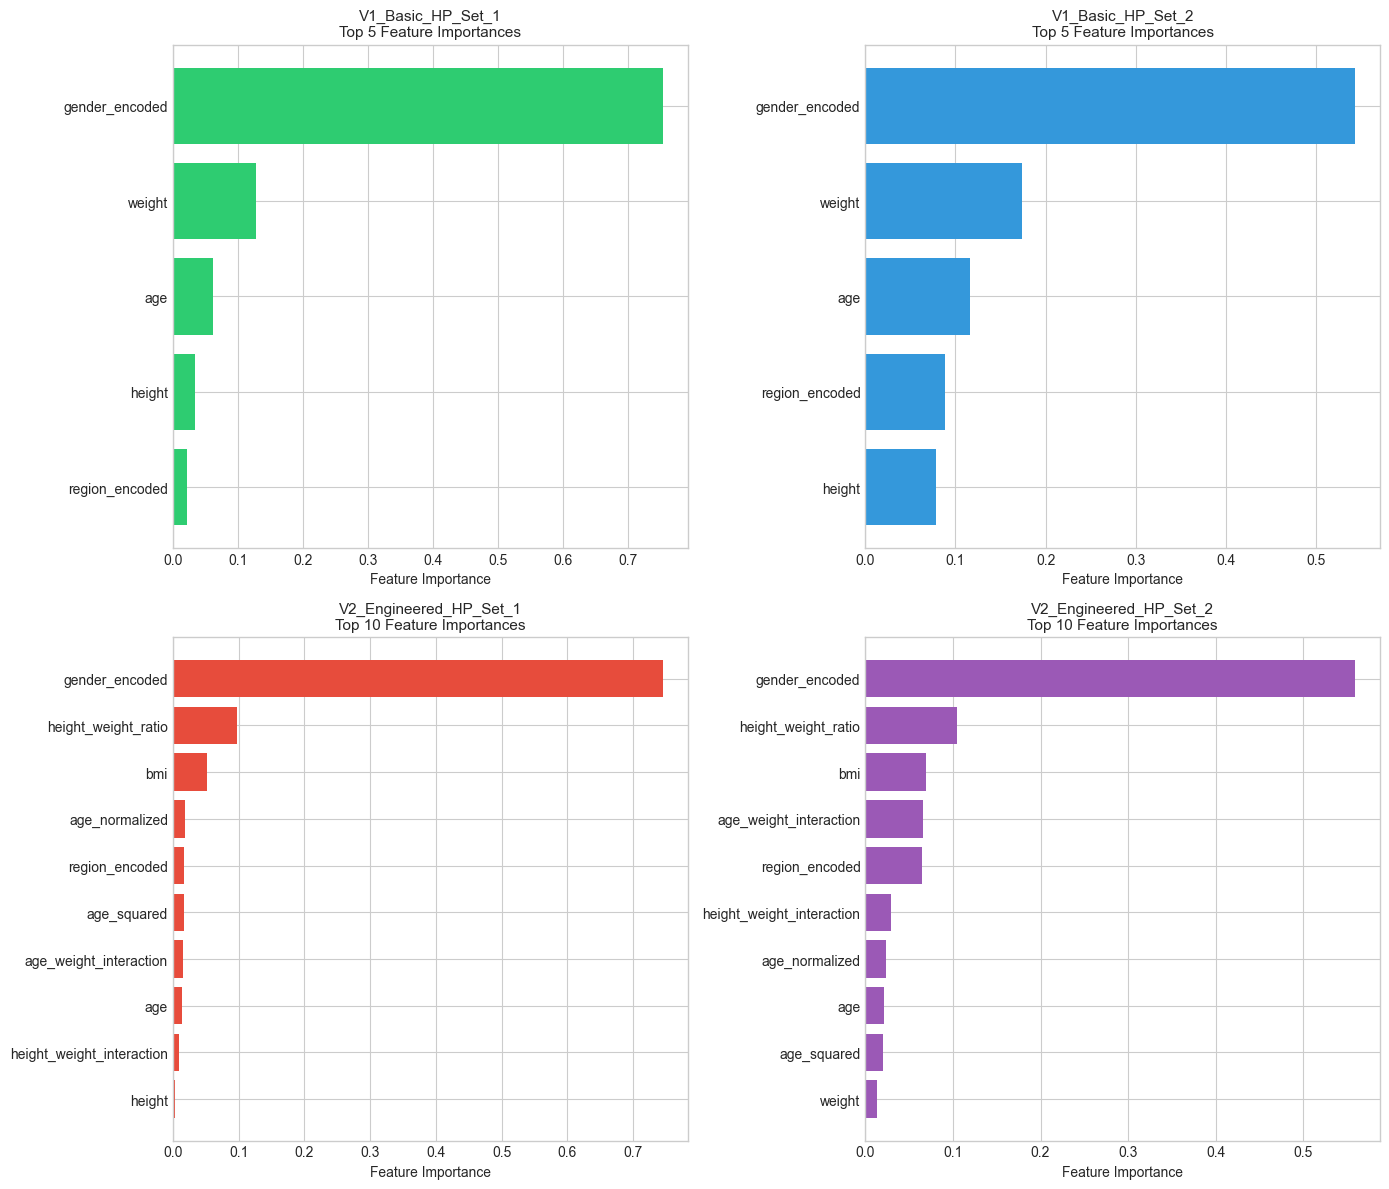

Saved: feature_importance.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    ax = axes[idx]
    model = result['model']
    feature_names = result['feature_cols']
    
    # Get feature importances
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Plot top 10 features
    top_n = min(10, len(feature_names))
    top_indices = indices[:top_n]
    
    ax.barh(range(top_n), importances[top_indices][::-1], color=colors[idx])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_indices[::-1]])
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(f"{result['run_name'].replace('RF_', '')}\nTop {top_n} Feature Importances", fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## 6.5 Train vs Test Performance (Overfitting Check)

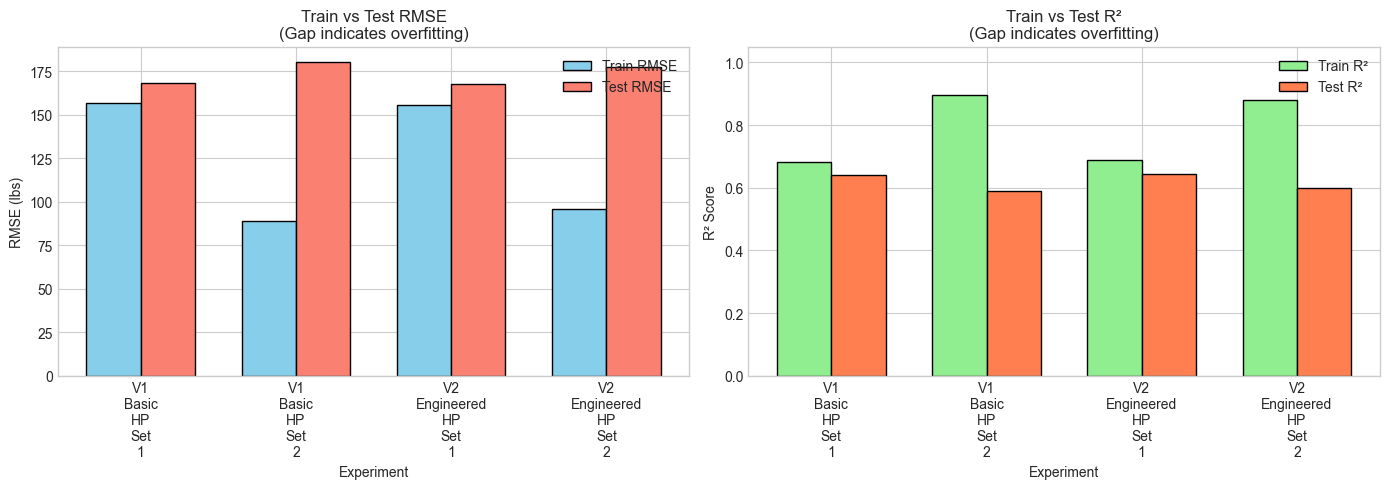

Saved: train_vs_test.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
ax1 = axes[0]
x = np.arange(len(all_results))
width = 0.35

train_rmse = [r['train_rmse'] for r in all_results]
test_rmse = [r['test_rmse'] for r in all_results]

bars1 = ax1.bar(x - width/2, train_rmse, width, label='Train RMSE', color='skyblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, test_rmse, width, label='Test RMSE', color='salmon', edgecolor='black')

ax1.set_xlabel('Experiment')
ax1.set_ylabel('RMSE (lbs)')
ax1.set_title('Train vs Test RMSE\n(Gap indicates overfitting)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results])
ax1.legend()

# R2 comparison
ax2 = axes[1]
train_r2 = [r['train_r2'] for r in all_results]
test_r2 = [r['test_r2'] for r in all_results]

bars1 = ax2.bar(x - width/2, train_r2, width, label='Train R²', color='lightgreen', edgecolor='black')
bars2 = ax2.bar(x + width/2, test_r2, width, label='Test R²', color='coral', edgecolor='black')

ax2.set_xlabel('Experiment')
ax2.set_ylabel('R² Score')
ax2.set_title('Train vs Test R²\n(Gap indicates overfitting)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([r['run_name'].replace('RF_', '').replace('_', '\n') for r in all_results])
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: train_vs_test.png")

## 6.6 Heatmap: Performance Matrix

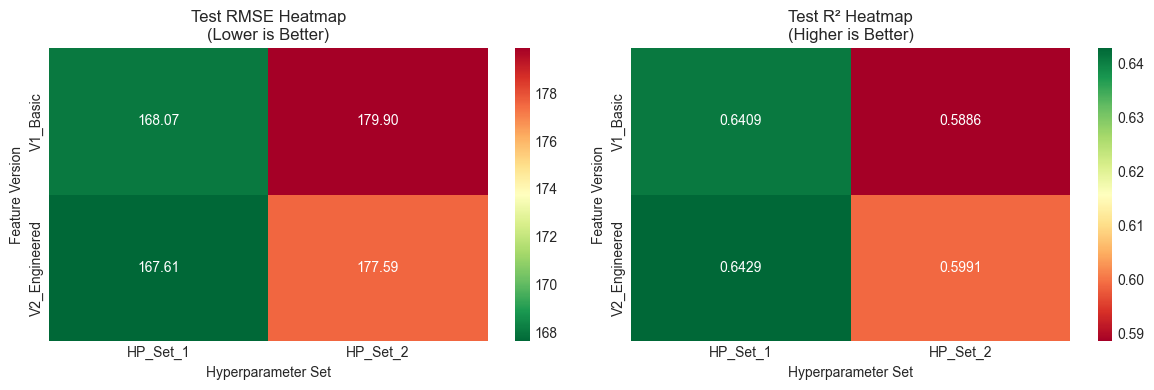

Saved: performance_heatmap.png


In [33]:
# Create pivot tables for heatmap
pivot_rmse = comparison_df.pivot(index='Feature Version', columns='Hyperparameter Set', values='Test RMSE')
pivot_r2 = comparison_df.pivot(index='Feature Version', columns='Hyperparameter Set', values='Test R2')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE heatmap
sns.heatmap(pivot_rmse, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('Test RMSE Heatmap\n(Lower is Better)', fontsize=12)

# R2 heatmap
sns.heatmap(pivot_r2, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title('Test R² Heatmap\n(Higher is Better)', fontsize=12)

plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: performance_heatmap.png")

---
# Part 7: Summary and Conclusions

In [34]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print("\n1. FEATURE STORE SETUP:")
print(f"   - Platform: Feast (local file-based)")
print(f"   - Feature V1 (Basic): {len(feature_cols_v1)} features")
print(f"   - Feature V2 (Engineered): {len(feature_cols_v2)} features")

print("\n2. ML PIPELINE:")
print(f"   - Platform: MLflow")
print(f"   - Algorithm: Random Forest Regressor")
print(f"   - Hyperparameter Sets: 2")
print(f"   - Total Experiments: 4")

print("\n3. FEATURE VERSIONS COMPARISON:")
v1_avg_r2 = comparison_df[comparison_df['Feature Version'] == 'V1_Basic']['Test R2'].mean()
v2_avg_r2 = comparison_df[comparison_df['Feature Version'] == 'V2_Engineered']['Test R2'].mean()
print(f"   - V1 (Basic) Avg R²: {v1_avg_r2:.4f}")
print(f"   - V2 (Engineered) Avg R²: {v2_avg_r2:.4f}")
print(f"   - Improvement: {((v2_avg_r2 - v1_avg_r2) / v1_avg_r2 * 100):.2f}%")

print("\n4. HYPERPARAMETER SETS COMPARISON:")
hp1_avg_r2 = comparison_df[comparison_df['Hyperparameter Set'] == 'HP_Set_1']['Test R2'].mean()
hp2_avg_r2 = comparison_df[comparison_df['Hyperparameter Set'] == 'HP_Set_2']['Test R2'].mean()
print(f"   - HP_Set_1 Avg R²: {hp1_avg_r2:.4f}")
print(f"   - HP_Set_2 Avg R²: {hp2_avg_r2:.4f}")

print("\n5. BEST CONFIGURATION:")
print(f"   - Experiment: {best_experiment['Experiment']}")
print(f"   - Test R²: {best_experiment['Test R2']:.4f}")
print(f"   - Test RMSE: {best_experiment['Test RMSE']:.2f} lbs")

print("\n6. KEY INSIGHTS:")
if v2_avg_r2 > v1_avg_r2:
    print("   - Feature engineering (V2) improved model performance")
else:
    print("   - Basic features (V1) performed comparably to engineered features")
    
# Check for overfitting
for r in all_results:
    train_test_gap = r['train_r2'] - r['test_r2']
    if train_test_gap > 0.1:
        print(f"   - {r['run_name']}: Shows signs of overfitting (gap={train_test_gap:.3f})")


FINAL SUMMARY

1. FEATURE STORE SETUP:
   - Platform: Feast (local file-based)
   - Feature V1 (Basic): 5 features
   - Feature V2 (Engineered): 14 features

2. ML PIPELINE:
   - Platform: MLflow
   - Algorithm: Random Forest Regressor
   - Hyperparameter Sets: 2
   - Total Experiments: 4

3. FEATURE VERSIONS COMPARISON:
   - V1 (Basic) Avg R²: 0.6148
   - V2 (Engineered) Avg R²: 0.6210
   - Improvement: 1.01%

4. HYPERPARAMETER SETS COMPARISON:
   - HP_Set_1 Avg R²: 0.6419
   - HP_Set_2 Avg R²: 0.5938

5. BEST CONFIGURATION:
   - Experiment: RF_V2_Engineered_HP_Set_1
   - Test R²: 0.6429
   - Test RMSE: 167.61 lbs

6. KEY INSIGHTS:
   - Feature engineering (V2) improved model performance
   - RF_V1_Basic_HP_Set_2: Shows signs of overfitting (gap=0.309)
   - RF_V2_Engineered_HP_Set_2: Shows signs of overfitting (gap=0.281)


In [35]:
# Save final comparison table
comparison_df.to_csv('experiment_results.csv', index=False)
print("\nSaved: experiment_results.csv")

# Display final table
print("\n" + "="*80)
print("COMPLETE RESULTS TABLE")
print("="*80)
display_cols = ['Experiment', 'Feature Version', 'Hyperparameter Set', 
                'Num Features', 'Test RMSE', 'Test MAE', 'Test R2']
print(comparison_df[display_cols].to_string(index=False))


Saved: experiment_results.csv

COMPLETE RESULTS TABLE
               Experiment Feature Version Hyperparameter Set  Num Features  Test RMSE   Test MAE  Test R2
     RF_V1_Basic_HP_Set_1        V1_Basic           HP_Set_1             5 168.074773 129.394749 0.640912
     RF_V1_Basic_HP_Set_2        V1_Basic           HP_Set_2             5 179.900428 139.069199 0.588604
RF_V2_Engineered_HP_Set_1   V2_Engineered           HP_Set_1            14 167.610463 128.981522 0.642894
RF_V2_Engineered_HP_Set_2   V2_Engineered           HP_Set_2            14 177.593614 136.701171 0.599087


---
# Part 8: MLflow Experiment Tracking & Model Registry

This section demonstrates how to:
1. Query experiments and runs from MLflow
2. Compare runs programmatically
3. Register the best model to the Model Registry
4. Load models for inference

## 8.1 Query MLflow Experiments

In [36]:
# List all runs in the experiment with full details
print("="*80)
print("MLFLOW EXPERIMENT TRACKING - ALL RUNS")
print("="*80)

runs_df = mlflow.search_runs(
    experiment_ids=[experiment_id],
    order_by=['metrics.test_r2 DESC']
)

# Display key columns
display_cols = [
    'run_id', 
    'tags.mlflow.runName',
    'params.feature_version', 
    'params.hp_set',
    'params.n_estimators',
    'params.max_depth',
    'metrics.test_r2', 
    'metrics.test_rmse',
    'metrics.test_mae'
]

print("\nAll Runs (sorted by Test R²):")
runs_df[display_cols]

MLFLOW EXPERIMENT TRACKING - ALL RUNS



All Runs (sorted by Test R²):


,run_id,tags.mlflow.runName,params.feature_version,params.hp_set,params.n_estimators,params.max_depth,metrics.test_r2,metrics.test_rmse,metrics.test_mae
0,1aa237f2e251422d914bd8654c6550d2,RF_V2_Engineered_HP_Set_1,V2_Engineered,HP_Set_1,50,10,0.642894,167.610463,128.981522
1,74b119b4dca24bb3b0e3496ebc083362,RF_V1_Basic_HP_Set_1,V1_Basic,HP_Set_1,50,10,0.640912,168.074773,129.394749
2,0e7bf8835615459f9eea1ead85f94f47,RF_V2_Engineered_HP_Set_2,V2_Engineered,HP_Set_2,200,20,0.599087,177.593614,136.701171
3,a7f179866f4942aa9cbeab80ff31a64f,RF_V1_Basic_HP_Set_2,V1_Basic,HP_Set_2,200,20,0.588604,179.900428,139.069199


In [37]:
# Get detailed info about each run
print("\n" + "="*80)
print("DETAILED RUN INFORMATION")
print("="*80)

for idx, row in runs_df.iterrows():
    run_id = row['run_id']
    run = client.get_run(run_id)
    
    print(f"\n--- Run: {run.data.tags.get('mlflow.runName', 'N/A')} ---")
    print(f"Run ID: {run_id}")
    print(f"Status: {run.info.status}")
    print(f"Start Time: {datetime.fromtimestamp(run.info.start_time/1000)}")
    print(f"\nParameters:")
    for key, value in sorted(run.data.params.items()):
        print(f"  {key}: {value}")
    print(f"\nMetrics:")
    for key, value in sorted(run.data.metrics.items()):
        print(f"  {key}: {value:.4f}")
    print(f"\nTags:")
    for key, value in sorted(run.data.tags.items()):
        if not key.startswith('mlflow.'):
            print(f"  {key}: {value}")


DETAILED RUN INFORMATION



--- Run: RF_V2_Engineered_HP_Set_1 ---
Run ID: 1aa237f2e251422d914bd8654c6550d2
Status: FINISHED
Start Time: 2026-04-22 14:51:35

Parameters:
  algorithm: RandomForestRegressor
  feature_version: V2_Engineered
  hp_set: HP_Set_1
  max_depth: 10
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 50
  num_features: 14
  random_state: 42
  test_samples: 10622
  test_size: 0.2
  train_samples: 42488

Metrics:
  test_mae: 128.9815
  test_r2: 0.6429
  test_rmse: 167.6105
  train_mae: 119.7992
  train_r2: 0.6872
  train_rmse: 155.3595
  train_test_r2_gap: 0.0443
  train_test_rmse_gap: 12.2510

Tags:
  author: ML Operations Student
  data_source: athletes.csv
  feature_store: Feast
  feature_version: V2_Engineered
  hyperparameter_set: HP_Set_1
  model_type: RandomForestRegressor
  stage: experiment



--- Run: RF_V1_Basic_HP_Set_1 ---
Run ID: 74b119b4dca24bb3b0e3496ebc083362
Status: FINISHED
Start Time: 2026-04-22 14:50:33.290000

Parameters:
  algorithm: RandomForestRegressor
  feature_version: V1_Basic
  hp_set: HP_Set_1
  max_depth: 10
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 50
  num_features: 5
  random_state: 42
  test_samples: 10622
  test_size: 0.2
  train_samples: 42488

Metrics:
  test_mae: 129.3947
  test_r2: 0.6409
  test_rmse: 168.0748
  train_mae: 120.8501
  train_r2: 0.6810
  train_rmse: 156.8804
  train_test_r2_gap: 0.0401
  train_test_rmse_gap: 11.1944

Tags:
  author: ML Operations Student
  data_source: athletes.csv
  feature_store: Feast
  feature_version: V1_Basic
  hyperparameter_set: HP_Set_1
  model_type: RandomForestRegressor
  stage: experiment

--- Run: RF_V2_Engineered_HP_Set_2 ---
Run ID: 0e7bf8835615459f9eea1ead85f94f47
Status: FINISHED
Start Time: 2026-04-22 14:51:49.053000

Parameters:
  algorithm: RandomForestRegressor
  feature_

## 8.2 Find Best Run and Register Model

In [38]:
# Find the best run based on test R2
best_run = runs_df.loc[runs_df['metrics.test_r2'].idxmax()]
best_run_id = best_run['run_id']

print("="*80)
print("BEST MODEL IDENTIFICATION")
print("="*80)
print(f"\nBest Run ID: {best_run_id}")
print(f"Run Name: {best_run['tags.mlflow.runName']}")
print(f"Feature Version: {best_run['params.feature_version']}")
print(f"Hyperparameter Set: {best_run['params.hp_set']}")
print(f"Test R²: {best_run['metrics.test_r2']:.4f}")
print(f"Test RMSE: {best_run['metrics.test_rmse']:.2f}")

BEST MODEL IDENTIFICATION

Best Run ID: 1aa237f2e251422d914bd8654c6550d2
Run Name: RF_V2_Engineered_HP_Set_1
Feature Version: V2_Engineered
Hyperparameter Set: HP_Set_1
Test R²: 0.6429
Test RMSE: 167.61


In [39]:
# Register the best model to MLflow Model Registry
MODEL_NAME = 'AthleteTotalLiftPredictor'

print("\n" + "="*80)
print("MODEL REGISTRATION")
print("="*80)

# Register the model
model_uri = f'runs:/{best_run_id}/model'
print(f"\nModel URI: {model_uri}")

try:
    # Register model
    model_details = mlflow.register_model(
        model_uri=model_uri,
        name=MODEL_NAME
    )
    
    print(f"\nModel registered successfully!")
    print(f"Model Name: {model_details.name}")
    print(f"Version: {model_details.version}")
    print(f"Status: {model_details.status}")
    
    # Add description to the model version
    client.update_model_version(
        name=MODEL_NAME,
        version=model_details.version,
        description=f"Best model from experiment. Feature Version: {best_run['params.feature_version']}, HP Set: {best_run['params.hp_set']}, Test R²: {best_run['metrics.test_r2']:.4f}"
    )
    
except Exception as e:
    print(f"Note: Model registration requires MLflow server. Error: {e}")
    print("The model is still logged and can be loaded using the run ID.")


MODEL REGISTRATION

Model URI: runs:/1aa237f2e251422d914bd8654c6550d2/model


Successfully registered model 'AthleteTotalLiftPredictor'.
2026/04/22 14:53:03 WARNING mlflow.tracking._model_registry.fluent: Run with id 1aa237f2e251422d914bd8654c6550d2 has no artifacts at artifact path 'model', registering model based on models:/m-d8ef8d4a22454c4791557359bd7a2093 instead



Model registered successfully!
Model Name: AthleteTotalLiftPredictor
Version: 1
Status: READY


Created version '1' of model 'AthleteTotalLiftPredictor'.


## 8.3 Load Model for Inference

In [40]:
# Load the best model from MLflow
print("="*80)
print("MODEL LOADING AND INFERENCE")
print("="*80)

# Load model from run
loaded_model = mlflow.sklearn.load_model(f'runs:/{best_run_id}/model')
print(f"\nLoaded model type: {type(loaded_model).__name__}")
print(f"Model parameters: {loaded_model.get_params()}")

# Make predictions on sample data
best_result = next(r for r in all_results if r['run_id'] == best_run_id)
sample_X = best_result['X_test'][:5]
sample_y_actual = best_result['y_test'].values[:5]

sample_predictions = loaded_model.predict(sample_X)

print("\nSample Predictions:")
for i, (actual, pred) in enumerate(zip(sample_y_actual, sample_predictions)):
    print(f"  Sample {i+1}: Actual={actual:.1f}, Predicted={pred:.1f}, Error={abs(actual-pred):.1f}")

MODEL LOADING AND INFERENCE



Loaded model type: RandomForestRegressor
Model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Sample Predictions:
  Sample 1: Actual=592.0, Predicted=607.7, Error=15.7
  Sample 2: Actual=1081.0, Predicted=1203.3, Error=122.3
  Sample 3: Actual=635.0, Predicted=578.5, Error=56.5
  Sample 4: Actual=1055.0, Predicted=1118.5, Error=63.5
  Sample 5: Actual=1150.0, Predicted=1334.9, Error=184.9


## 8.4 List Artifacts from Best Run

In [41]:
# List all artifacts logged for the best run
print("="*80)
print("ARTIFACTS LOGGED IN BEST RUN")
print("="*80)

def list_artifacts_recursive(run_id, path=''):
    """Recursively list all artifacts."""
    artifacts = client.list_artifacts(run_id, path)
    for artifact in artifacts:
        if artifact.is_dir:
            print(f"📁 {artifact.path}/")
            list_artifacts_recursive(run_id, artifact.path)
        else:
            print(f"   📄 {artifact.path} ({artifact.file_size} bytes)")

print(f"\nArtifacts for Run: {best_run_id}")
list_artifacts_recursive(best_run_id)

ARTIFACTS LOGGED IN BEST RUN

Artifacts for Run: 1aa237f2e251422d914bd8654c6550d2


📁 analysis/
   📄 analysis/feature_importance.csv (506 bytes)
   📄 analysis/predictions.csv (476819 bytes)
📁 config/
   📄 config/feature_info.json (390 bytes)
📁 plots/
   📄 plots/prediction_plot.png (70510 bytes)
📁 preprocessing/


   📄 preprocessing/scaler.joblib (1383 bytes)


## 8.5 Compare Runs Programmatically

In [42]:
# Compare all runs in a formatted table
print("="*80)
print("MLFLOW RUNS COMPARISON TABLE")
print("="*80)

comparison_table = runs_df[[
    'tags.mlflow.runName',
    'params.feature_version',
    'params.hp_set',
    'params.num_features',
    'metrics.train_r2',
    'metrics.test_r2',
    'metrics.train_rmse',
    'metrics.test_rmse',
    'metrics.train_test_r2_gap'
]].copy()

comparison_table.columns = ['Run Name', 'Features', 'HP Set', 'Num Features', 
                            'Train R²', 'Test R²', 'Train RMSE', 'Test RMSE', 'Overfit Gap']
comparison_table = comparison_table.round(4)
print(comparison_table.to_string(index=False))

MLFLOW RUNS COMPARISON TABLE
                 Run Name      Features   HP Set Num Features  Train R²  Test R²  Train RMSE  Test RMSE  Overfit Gap
RF_V2_Engineered_HP_Set_1 V2_Engineered HP_Set_1           14    0.6872   0.6429    155.3595   167.6105       0.0443
     RF_V1_Basic_HP_Set_1      V1_Basic HP_Set_1            5    0.6810   0.6409    156.8804   168.0748       0.0401
RF_V2_Engineered_HP_Set_2 V2_Engineered HP_Set_2           14    0.8804   0.5991     96.0565   177.5936       0.2813
     RF_V1_Basic_HP_Set_2      V1_Basic HP_Set_2            5    0.8974   0.5886     88.9878   179.9004       0.3088


---
# Appendix: MLflow UI Instructions

To view the MLflow UI with all experiments, runs, and artifacts:

```bash
# Navigate to the project directory
cd "Machine Learning Operations"

# Start MLflow UI server
mlflow ui --port 5000
```

Then open http://localhost:5000 in your browser to:
- View all experiments and runs
- Compare metrics across runs
- View logged parameters and tags
- Download artifacts (models, plots, data)
- Access the Model Registry

In [43]:
print("\n" + "="*80)
print("ASSIGNMENT COMPLETE!")
print("="*80)
print("""
MLFLOW TRACKING SUMMARY:
========================
- Experiment: {}
- Total Runs: {}
- Best Model R²: {:.4f}
- Model Registry: {}

FILES GENERATED:
================
1. feature_store/          - Feast feature store with V1 and V2 features
2. mlruns/                 - MLflow experiment tracking (parameters, metrics, models, artifacts)
3. metrics_comparison.png  - Bar chart comparing metrics
4. actual_vs_predicted.png - Scatter plots of predictions
5. residual_distribution.png - Residual histograms
6. feature_importance.png  - Feature importance plots
7. train_vs_test.png       - Overfitting analysis
8. performance_heatmap.png - Performance matrix heatmap
9. experiment_results.csv  - Complete results table

MLFLOW ARTIFACTS PER RUN:
=========================
- model/                   - Trained sklearn model with signature
- config/feature_info.json - Feature configuration
- preprocessing/scaler.joblib - StandardScaler for inference
- analysis/feature_importance.csv - Feature importances
- analysis/predictions.csv - Test set predictions
- plots/prediction_plot.png - Actual vs Predicted visualization
""".format(
    EXPERIMENT_NAME,
    len(runs_df),
    runs_df['metrics.test_r2'].max(),
    MODEL_NAME
))


ASSIGNMENT COMPLETE!

MLFLOW TRACKING SUMMARY:
- Experiment: Athlete_TotalLift_Prediction
- Total Runs: 4
- Best Model R²: 0.6429
- Model Registry: AthleteTotalLiftPredictor

FILES GENERATED:
1. feature_store/          - Feast feature store with V1 and V2 features
2. mlruns/                 - MLflow experiment tracking (parameters, metrics, models, artifacts)
3. metrics_comparison.png  - Bar chart comparing metrics
4. actual_vs_predicted.png - Scatter plots of predictions
5. residual_distribution.png - Residual histograms
6. feature_importance.png  - Feature importance plots
7. train_vs_test.png       - Overfitting analysis
8. performance_heatmap.png - Performance matrix heatmap
9. experiment_results.csv  - Complete results table

MLFLOW ARTIFACTS PER RUN:
- model/                   - Trained sklearn model with signature
- config/feature_info.json - Feature configuration
- preprocessing/scaler.joblib - StandardScaler for inference
- analysis/feature_importance.csv - Feature importance